# Camada Analítica (Business Answers)

Nesta camada (Gold Layer), utilizamos a tabela limpa e padronizada proveniente da **Camada Silver** (`vw_silver_nyc_taxi_consumption`) para responder às perguntas de negócio do case. 

Para garantir a acurácia dos dados financeiros e de operação, foram aplicadas as seguintes premissas analíticas:
* Valores totais (`total_amount`) negativos ou zerados foram removidos das agregações financeiras para não distorcer a média com estornos de cartão.
* Contagens de passageiros inválidas foram removidas da média horária.
* Uma coluna de volume (`total_trips`) foi adicionada lado a lado com a média para dar visibilidade da significância da amostra.

In [0]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "matplotlib", "pandas", "-q"])

import matplotlib
matplotlib.use('Agg') 
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import numpy as np
from pyspark.sql.functions import (
    col, round as spark_round, avg, count,
    hour, month, to_timestamp, lit, year
)
import base64
from IPython.display import display, Image as IPImage


[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


## Pergunta 1
**Qual a média do `total_amount` por mês (apenas para a frota Yellow)?**

+------------+----------------+-----------+
|pickup_month|avg_total_amount|total_trips|
+------------+----------------+-----------+
|           1|           27.45|    3039875|
|           2|           27.34|    2887317|
|           3|           28.27|    3371881|
|           4|           28.76|    3256849|
|           5|           29.46|    3480251|
+------------+----------------+-----------+

Gráfico salvo em: q1_receita_mensal.png


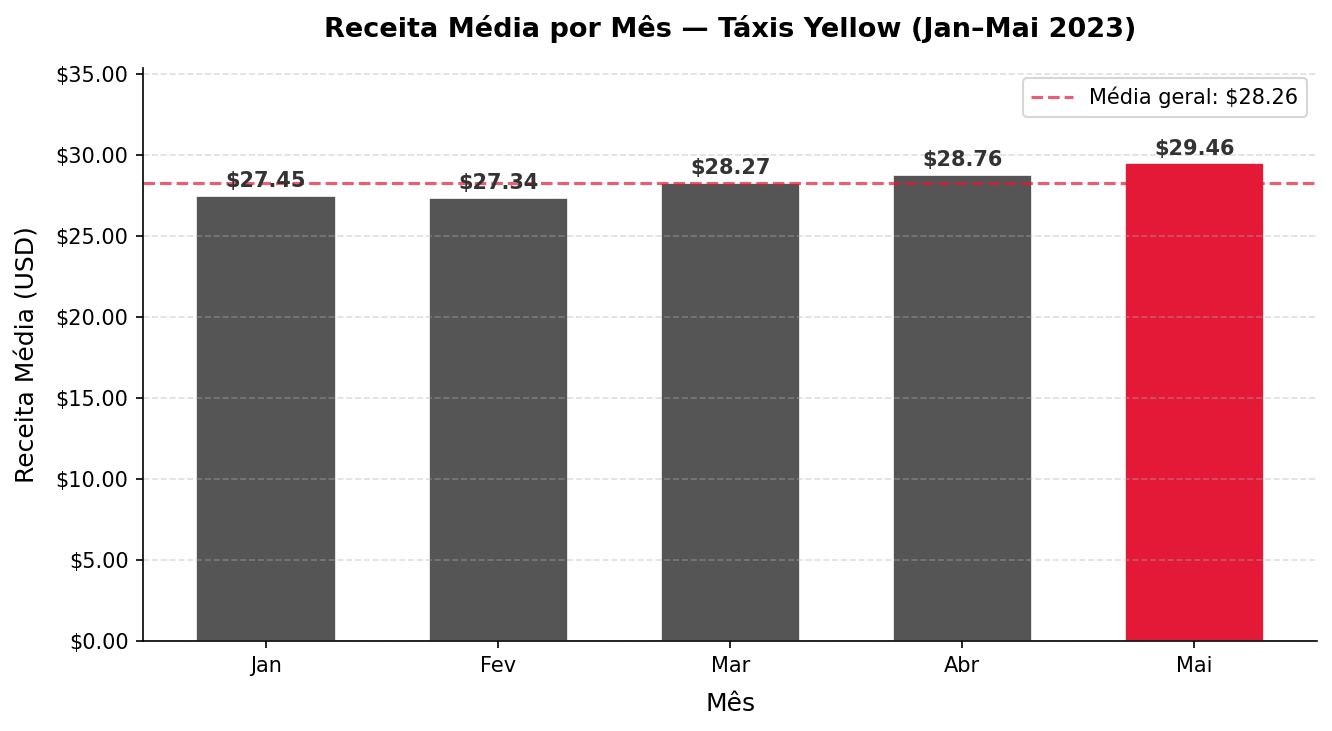

In [0]:
# Q1: Média de total_amount por mês para táxis Yellow
df_q1 = (
    spark.table("vw_silver_nyc_taxi_consumption")
    .filter((col("taxi_type") == "yellow") & (col("total_amount") > 0))
    .groupBy("pickup_month")
    .agg(
        spark_round(avg("total_amount"), 2).alias("avg_total_amount"),
        count("*").alias("total_trips")
    )
    .orderBy("pickup_month")
)
df_q1.show()

# Converter para pandas
pdf_q1 = df_q1.toPandas()
month_labels = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai']
pdf_q1['month_label'] = [month_labels[m-1] for m in pdf_q1['pickup_month']]
pdf_q1 = pdf_q1.sort_values('pickup_month').reset_index(drop=True)

# ── Gráfico de barras com linha de tendência ──────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
bar_colors = ['#555555'] * len(pdf_q1)
max_idx = pdf_q1['avg_total_amount'].idxmax()
bar_colors[max_idx] = '#E31937'  # destaque iFood no mês de maior receita

bars = ax.bar(pdf_q1['month_label'], pdf_q1['avg_total_amount'],
              color=bar_colors, edgecolor='white', linewidth=0.8, width=0.6)

mean_val = pdf_q1['avg_total_amount'].mean()
ax.axhline(mean_val, color='#E31937', linestyle='--', linewidth=1.5,
           alpha=0.7, label=f'Média geral: ${mean_val:.2f}')

for bar, val in zip(bars, pdf_q1['avg_total_amount']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'${val:.2f}', ha='center', va='bottom',
            fontsize=10, fontweight='bold', color='#333333')

ax.set_xlabel('Mês', fontsize=12, labelpad=8)
ax.set_ylabel('Receita Média (USD)', fontsize=12, labelpad=8)
ax.set_title('Receita Média por Mês — Táxis Yellow (Jan–Mai 2023)',
             fontsize=13, fontweight='bold', pad=15)
ax.legend(fontsize=10)
ax.set_ylim(0, pdf_q1['avg_total_amount'].max() * 1.2)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.2f'))
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()

# Salvar e exibir
q1_path = 'q1_receita_mensal.png'
fig.savefig(q1_path, dpi=150, bbox_inches='tight')
print(f"Gráfico salvo em: {q1_path}")

with open(q1_path, 'rb') as f:
    display(IPImage(data=f.read(), format='png'))

plt.close()


### 📊 Interpretação

A receita média apresenta uma queda pontual em fevereiro ($27,34 — mês mais curto do ano) e cresce consistentemente de março até maio ($29,46 — pico do período).
A variação total de apenas 7,7% entre os extremos é coerente com um mercado de tarifas reguladas pela NYC TLC,
onde oscilações refletem distância média das corridas, não ajuste de preço. Uma análise da distância média
por mês confirmaria essa hipótese.

## Pergunta 2
**Qual a média do `passenger_count` por hora do dia para as viagens que aconteceram em Maio (Para TODOS os Táxis)?**

+-----------+-------------------+-----------+
|pickup_hour|avg_passenger_count|total_trips|
+-----------+-------------------+-----------+
|          0|               1.43|      90817|
|          1|               1.43|      59122|
|          2|               1.45|      38166|
|          3|               1.45|      25042|
|          4|                1.4|      16475|
|          5|               1.28|      18850|
|          6|               1.26|      46919|
|          7|               1.28|      94738|
|          8|               1.29|     129158|
|          9|               1.31|     145051|
|         10|               1.35|     157878|
|         11|               1.36|     172032|
|         12|               1.37|     185406|
|         13|               1.38|     189469|
|         14|               1.39|     206462|
|         15|                1.4|     211211|
|         16|                1.4|     211716|
|         17|               1.39|     230929|
|         18|               1.38| 

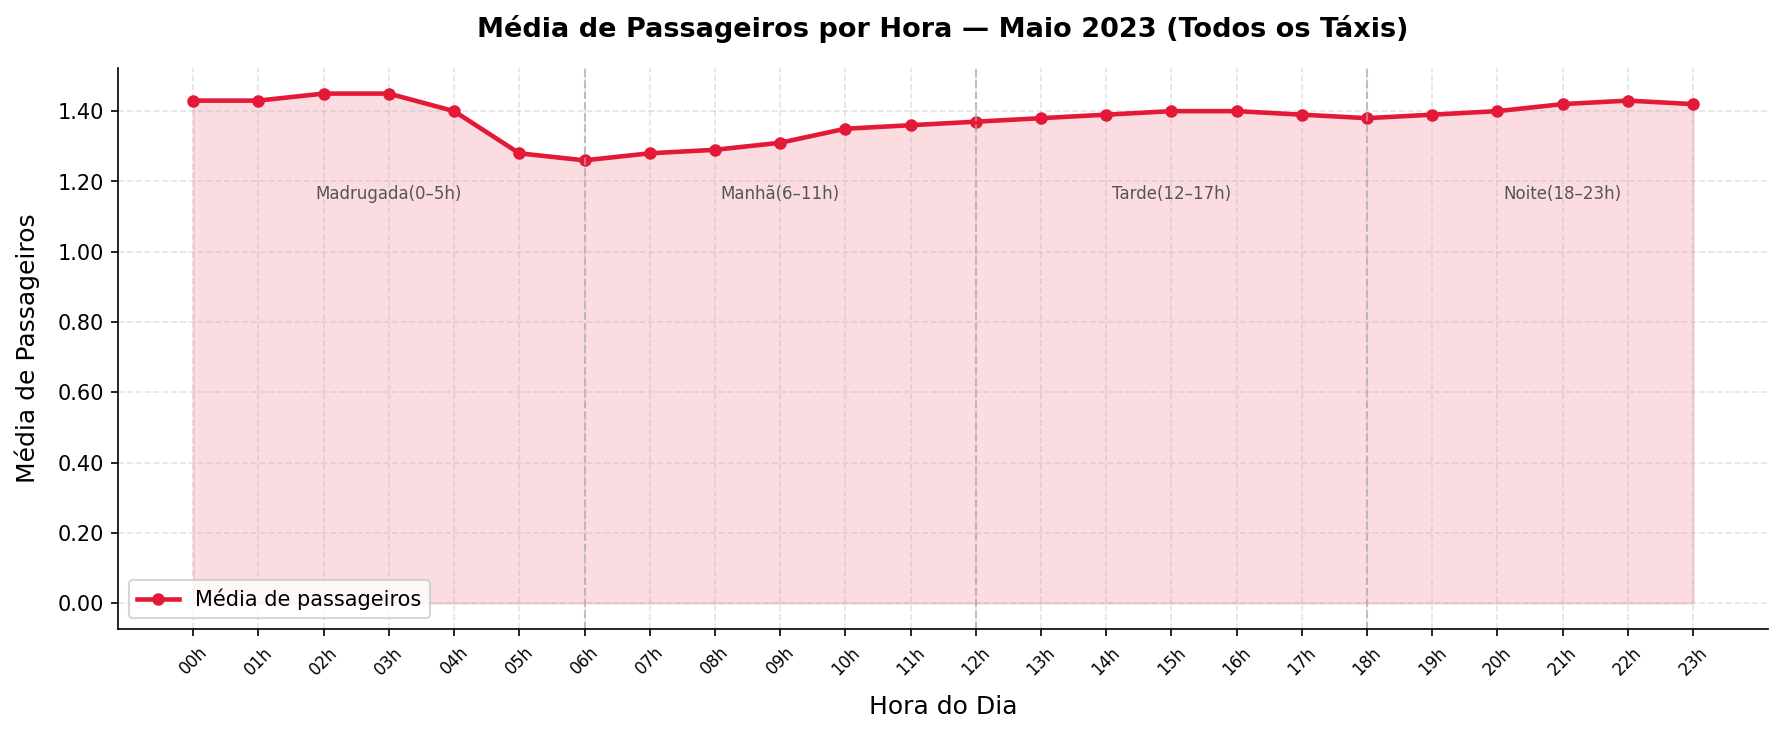

In [0]:
df_q2 = (
    spark.table("vw_silver_nyc_taxi_consumption")
    .filter((col("pickup_month") == 5) & (col("passenger_count") > 0))
    .withColumn("pickup_hour", hour("tpep_pickup_datetime"))
    .groupBy("pickup_hour")
    .agg(
        spark_round(avg("passenger_count"), 2).alias("avg_passenger_count"),
        count("*").alias("total_trips")
    )
    .orderBy("pickup_hour")
)
df_q2.show(24)

pdf_q2 = df_q2.toPandas().sort_values("pickup_hour").reset_index(drop=True)

# ── Gráfico de linha com área sombreada ───────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(12, 5))

ax2.fill_between(pdf_q2['pickup_hour'], pdf_q2['avg_passenger_count'],
                 alpha=0.15, color='#E31937')
ax2.plot(pdf_q2['pickup_hour'], pdf_q2['avg_passenger_count'],
         color='#E31937', linewidth=2.2, marker='o', markersize=5,
         label='Média de passageiros')

# Períodos do dia
periods = [
    (0, 6, 'Madrugada(0–5h)'),
    (6, 12, 'Manhã(6–11h)'),
    (12, 18, 'Tarde(12–17h)'),
    (18, 24, 'Noite(18–23h)')
]
y_min = pdf_q2['avg_passenger_count'].min()
for start, end, label in periods:
    if start > 0:
        ax2.axvline(start, color='#AAAAAA', linestyle='--', linewidth=1, alpha=0.7)
    ax2.text((start + end) / 2, y_min - 0.07, label,
             ha='center', va='top', fontsize=8, color='#555555')

ax2.set_xlabel('Hora do Dia', fontsize=12, labelpad=8)
ax2.set_ylabel('Média de Passageiros', fontsize=12, labelpad=8)
ax2.set_title('Média de Passageiros por Hora — Maio 2023 (Todos os Táxis)',
              fontsize=13, fontweight='bold', pad=15)
ax2.set_xticks(range(24))
ax2.set_xticklabels([f'{h:02d}h' for h in range(24)], fontsize=8, rotation=45)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
ax2.grid(linestyle='--', alpha=0.35)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.legend(fontsize=10)
plt.tight_layout()

q2_path = 'q2_passageiros_hora.png'
fig2.savefig(q2_path, dpi=150, bbox_inches='tight')
print(f"Gráfico salvo em: {q2_path}")

with open(q2_path, 'rb') as f:
    display(IPImage(data=f.read(), format='png'))

plt.close()


### 📊 Interpretação

A média de passageiros permanece em uma faixa estreita ao longo do dia (1,26–1,45), indicando que
corridas individuais dominam em todos os períodos. O pico ocorre paradoxalmente na madrugada (2h–3h: 1,45),
quando o volume é baixo (≈40K corridas/hora) mas as corridas tendem a ser em grupo. O vale se dá às 6h (1,26), horário de commute individual
de trabalhadores. Cruzar esse indicador com `total_amount` por hora revelaria se as corridas de madrugada,
apesar de menores em volume, compensam em receita média.
